In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.decomposition import PCA

In [8]:
df = pd.read_csv('danawa4.csv', encoding='utf-8-sig')
print(df.shape)
df.head()

(863, 26)


,제품명,브랜드,AI여부,CPU브랜드,CPU등급,그래픽,RAM(GB),배터리용량,무게(kg),화면크기(인치),...,용도_휴대용,has_rating,별점,외장그래픽,등록일,등록_경과월,Cluster,OS_프리도스,OS_윈도우11,OS_macOS
0,LG전자 2026 그램 프로16 16Z90U-KU7WK,LG전자,1,인텔,7,내장,32.0,77.0,1.190,16.0,...,0,1,4.9,0,26.01.,2,4,0,1,0
1,LG전자 2025 그램 프로16 16Z90TS-GU7WK,LG전자,1,인텔,7,내장,32.0,77.0,1.199,16.0,...,0,1,4.9,0,25.03.,12,4,0,1,0
2,HP 오멘 16-ap0117AX,HP,0,AMD,9,외장,32.0,83.0,2.350,16.0,...,0,1,4.8,1,25.06.,9,3,1,0,0
3,에이서 프레데터 헬리오스 네오 16 AI PHN16-73-9797,에이서,1,인텔,9,외장,32.0,90.0,2.450,16.0,...,0,1,5.0,1,25.07.,8,5,1,0,0
4,레노버 LEGION 5 15IRX10 i7 5060,레노버,0,인텔,7,외장,16.0,80.0,1.900,15.1,...,0,1,4.6,1,25.08.,7,3,1,0,0


In [9]:
lg = df[df['브랜드'].str.contains('LG', na=False)]
print(f'LG 제품 수: {len(lg)}')
print(lg['Cluster'].value_counts().sort_index())

LG 제품 수: 176
Cluster
0    20
1    76
3     7
4    65
5     8
Name: count, dtype: int64


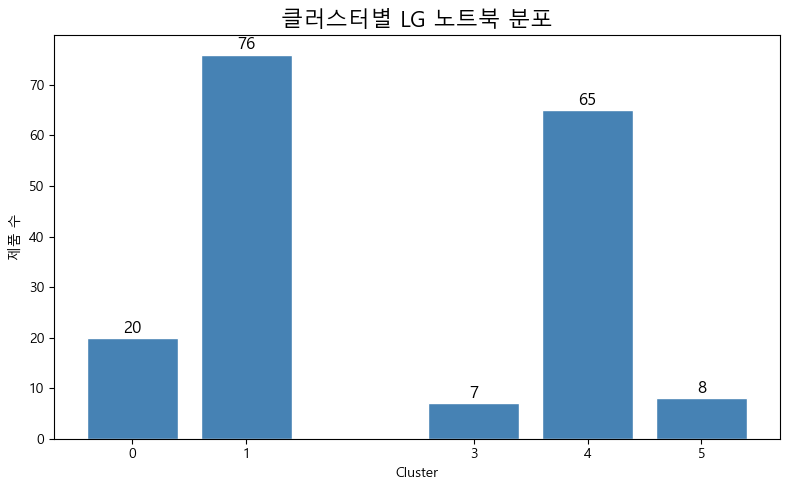

In [10]:
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()

cluster_counts = lg['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(cluster_counts.index, cluster_counts.values, color='steelblue', edgecolor='white')

for bar, val in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontsize=12)

plt.title('클러스터별 LG 노트북 분포', fontproperties=font_prop, fontsize=16)
plt.xlabel('Cluster', fontproperties=font_prop)
plt.ylabel('제품 수', fontproperties=font_prop)
plt.xticks(cluster_counts.index)
plt.tight_layout()
plt.savefig('lg_cluster_bar.png', dpi=150)
plt.show()

C:\Users\유정민\AppData\Local\Temp\ipykernel_37684\436163253.py:26: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\유정민\AppData\Local\Temp\ipykernel_37684\436163253.py:27: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig('lg_pca.png', dpi=150, bbox_inches='tight')
c:\Users\유정민\Desktop\my-crawler\클러스터\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


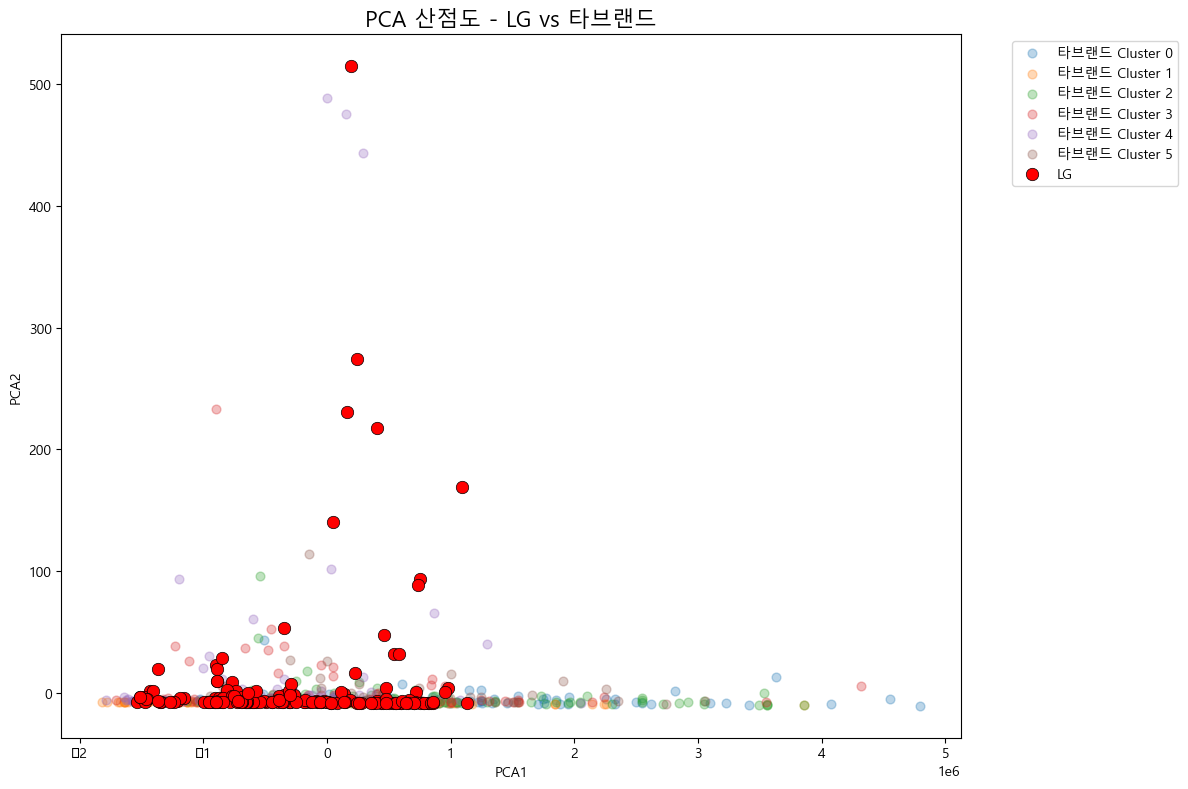

In [11]:
features = ['CPU등급', '배터리용량', '무게(kg)', '화면크기(인치)', '가격', '리뷰수', 'AI여부', '외장그래픽', '별점']

X = df[features].fillna(0)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]
df['is_LG'] = df['브랜드'].str.contains('LG', na=False)

plt.figure(figsize=(12, 8))

others = df[~df['is_LG']]
for cluster in sorted(others['Cluster'].unique()):
    subset = others[others['Cluster'] == cluster]
    plt.scatter(subset['PCA1'], subset['PCA2'], alpha=0.3, s=40, label=f'타브랜드 Cluster {cluster}')

lg_pca = df[df['is_LG']]
plt.scatter(lg_pca['PCA1'], lg_pca['PCA2'], color='red', s=80,
            edgecolor='black', linewidth=0.5, label='LG', zorder=5)

plt.title('PCA 산점도 - LG vs 타브랜드', fontproperties=font_prop, fontsize=16)
plt.xlabel('PCA1', fontproperties=font_prop)
plt.ylabel('PCA2', fontproperties=font_prop)
plt.legend(prop=font_prop, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('lg_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
lg[['제품명', 'Cluster', '가격', '무게(kg)', 'CPU등급', '외장그래픽', 'AI여부', '별점']]\
    .sort_values('Cluster')\
    .reset_index(drop=True)

,제품명,Cluster,가격,무게(kg),CPU등급,외장그래픽,AI여부,별점
0,LG전자 2025 그램 프로16 16ZD90TR-EX79K WIN11,0,3229000,1.36,7,1,1,0.0
1,LG전자 2025 그램 프로16 16Z90TR-ED7WK,0,3182630,1.36,7,1,1,4.9
2,LG전자 2025 그램 프로17 17Z90TR-EP7CL,0,3574170,1.48,7,1,1,0.0
3,LG전자 2025 그램 프로17 17Z90TR-ED7HK,0,3420730,1.48,7,1,1,5.0
4,LG전자 2025 그램 프로16 16ZD90TR-EX7BK WIN11,0,3216370,1.36,7,1,1,0.0
...,...,...,...,...,...,...,...,...
171,LG전자 2025 그램 프로17 17ZD90TR-SX79K,5,2918990,1.48,7,1,1,3.6
172,LG전자 2025 그램 프로17 17ZD90TR-EX7BK,5,3099000,1.48,7,1,1,0.0
173,LG전자 2025 그램 프로17 17ZD90TR-SXSWK,5,3004000,1.48,7,1,1,0.0
174,LG전자 2025 그램 프로17 17ZD90TR-SX7BK,5,3104970,1.48,7,1,1,5.0
